In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/HDFCBANK.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/GRASIM.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/WIPRO.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/stock_metadata.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/BPCL.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/INFY.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/LT.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/RELIANCE.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/BRITANNIA.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/INFRATEL.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/HEROMOTOCO.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/HINDUNILVR.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/TATAMOTORS.csv
/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/MM.csv
/kaggle/input/data

In [3]:
file_path = "/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/RELIANCE.csv"

df = pd.read_csv(file_path)

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [4]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [5]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (5306, 15)

Data types:
Date                   object
Symbol                 object
Series                 object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
%Deliverble           float64
dtype: object

Missing values:
Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df = df.sort_values("Date").reset_index(drop=True)

In [8]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [9]:
df.tail()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
5301,2021-04-26,RELIANCE,EQ,1904.35,1920.00,1962.0,1911.50,1938.00,1937.85,1941.32,9620785,1.867699e+15,259137.0,4276703.0,0.4445
5302,2021-04-27,RELIANCE,EQ,1937.85,1940.00,1997.2,1938.25,1990.00,1988.65,1978.64,9226547,1.825602e+15,291197.0,3772144.0,0.4088
5303,2021-04-28,RELIANCE,EQ,1988.65,1997.85,2008.0,1980.15,1993.15,1997.30,1997.60,7902002,1.578508e+15,247331.0,3921560.0,0.4963
5304,2021-04-29,RELIANCE,EQ,1997.30,2022.90,2044.5,2007.30,2020.00,2024.05,2024.21,8035915,1.626634e+15,213153.0,2834103.0,0.3527
5305,2021-04-30,RELIANCE,EQ,2024.05,2008.50,2036.0,1987.55,1995.90,1994.50,2010.20,9150974,1.839532e+15,288687.0,3902504.0,0.4265


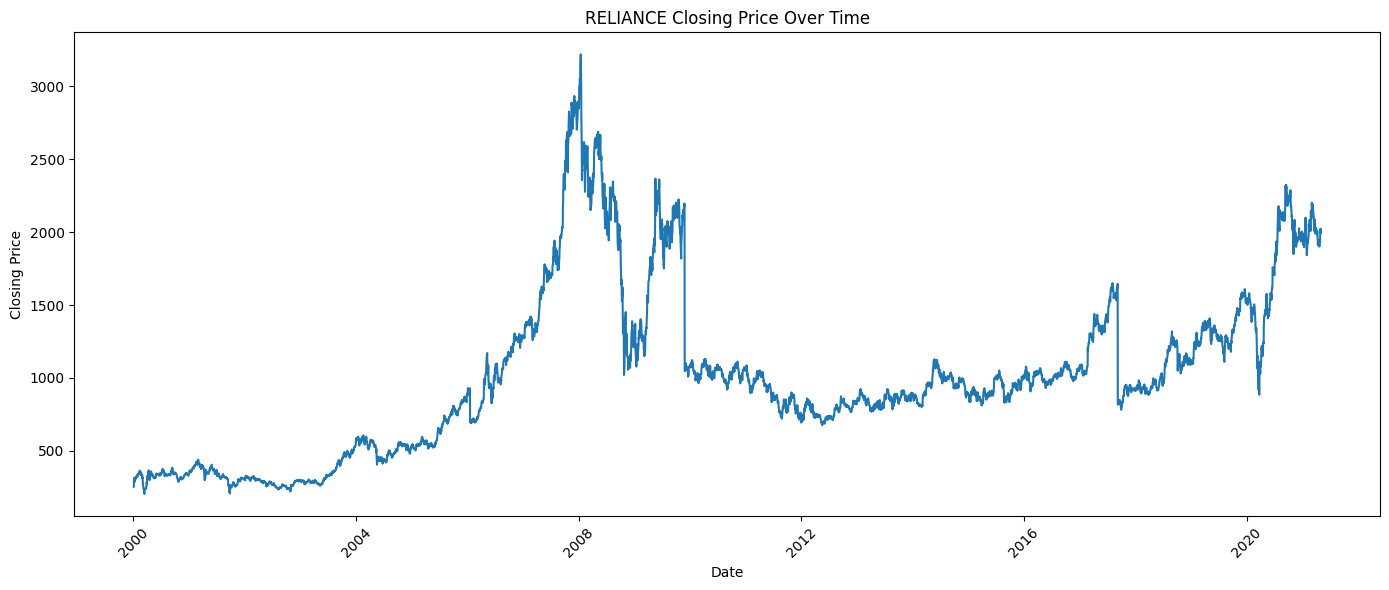

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("RELIANCE Closing Price Over Time")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
df.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64

In [12]:
data = df[["Close"]].copy()

data.head()

,Close
0,251.70
1,271.85
2,282.50
3,294.35
4,314.55


In [13]:
# Previous 30 closing prices
#               ↓
#              LSTM
#               ↓
# Next closing price

In [14]:
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

print("Total:", len(data))
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Total: 5306
Train: 3714
Validation: 796
Test: 796


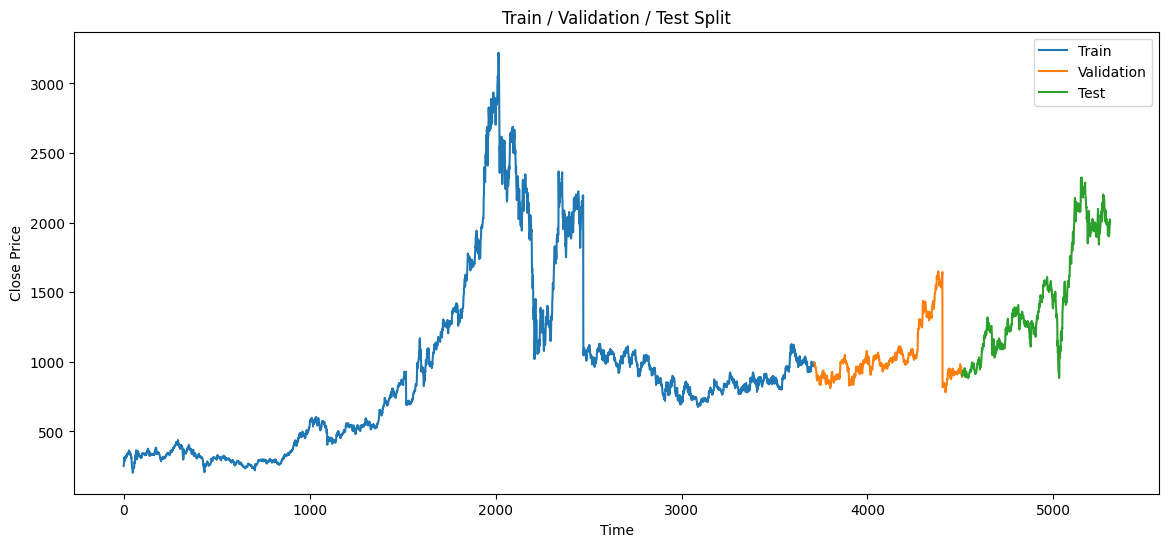

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_data.index,
    train_data["Close"],
    label="Train"
)

plt.plot(
    val_data.index,
    val_data["Close"],
    label="Validation"
)

plt.plot(
    test_data.index,
    test_data["Close"],
    label="Test"
)

plt.title("Train / Validation / Test Split")

plt.xlabel("Time")
plt.ylabel("Close Price")

plt.legend()

plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [17]:
scaler.fit(train_data[["Close"]])

MinMaxScaler()

In [18]:
scaled_data = scaler.transform(data[["Close"]])

In [19]:
print(scaled_data[:5])

[[0.01607211]
 [0.02274949]
 [0.02627873]
 [0.03020562]
 [0.03689957]]


In [20]:
def create_sequences(data, window_size):
    
    X = []
    y = []
    
    for i in range(window_size, len(data)):
        
        X.append(data[i-window_size:i])
        y.append(data[i])
    
    return np.array(X), np.array(y)

In [21]:
window_size = 30

In [22]:
train_scaled = scaled_data[:train_end]

X_train, y_train = create_sequences(
    train_scaled,
    window_size
)

In [23]:
val_start = train_end - window_size

val_scaled = scaled_data[
    val_start:val_end
]

X_val, y_val = create_sequences(
    val_scaled,
    window_size
)

In [24]:
test_start = val_end - window_size

test_scaled = scaled_data[
    test_start:
]

X_test, y_test = create_sequences(
    test_scaled,
    window_size
)

In [25]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3684, 30, 1)
y_train: (3684, 1)
X_val: (796, 30, 1)
y_val: (796, 1)
X_test: (796, 30, 1)
y_test: (796, 1)


In [26]:
print("One input sequence:")
print(X_train[0])

print("\nTarget:")
print(y_train[0])

One input sequence:
[[0.01607211]
 [0.02274949]
 [0.02627873]
 [0.03020562]
 [0.03689957]
 [0.0348947 ]
 [0.02826703]
 [0.03264129]
 [0.03600484]
 [0.0374795 ]
 [0.03497755]
 [0.03678359]
 [0.03857306]
 [0.03633622]
 [0.0408099 ]
 [0.04074363]
 [0.03868905]
 [0.0436598 ]
 [0.04478651]
 [0.04140639]
 [0.04336156]
 [0.045383  ]
 [0.04588007]
 [0.04670853]
 [0.04652627]
 [0.04612861]
 [0.04877968]
 [0.05055258]
 [0.05305453]
 [0.04934303]]

Target:
[0.04677481]


In [27]:
print("Sequence shape:", X_train[0].shape)

Sequence shape: (30, 1)


In [28]:
model = keras.Sequential([
    
    layers.Input(shape=(window_size, 1)),
    
    layers.LSTM(64),
    
    layers.Dense(32, activation="relu"),
    
    layers.Dense(1)
])

2026-10-09 14:19:24.217833: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [31]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    
    validation_data=(X_val, y_val),
    
    epochs=50,
    batch_size=32,
    
    callbacks=[early_stopping],
    
    shuffle=False
)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0015 - mae: 0.0245 - val_loss: 8.4040e-04 - val_mae: 0.0189
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0019 - mae: 0.0291 - val_loss: 7.8400e-04 - val_mae: 0.0178
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0021 - mae: 0.0326 - val_loss: 0.0024 - val_mae: 0.0364
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0031 - mae: 0.0366 - val_loss: 5.5023e-04 - val_mae: 0.0168
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0019 - mae: 0.0318 - val_loss: 4.8685e-04 - val_mae: 0.0155
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0016 - mae: 0.0294 - val_loss: 4.7589e-04 - val_mae: 0.0152
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0014 - mae: 0.0274 - val_loss: 4.1144e-04 - val_mae: 0.0128
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0012 - mae: 0.0256 - val_loss: 3.6859e-04 - val_mae: 0.0119
Epoch 9/50
116/116 ━

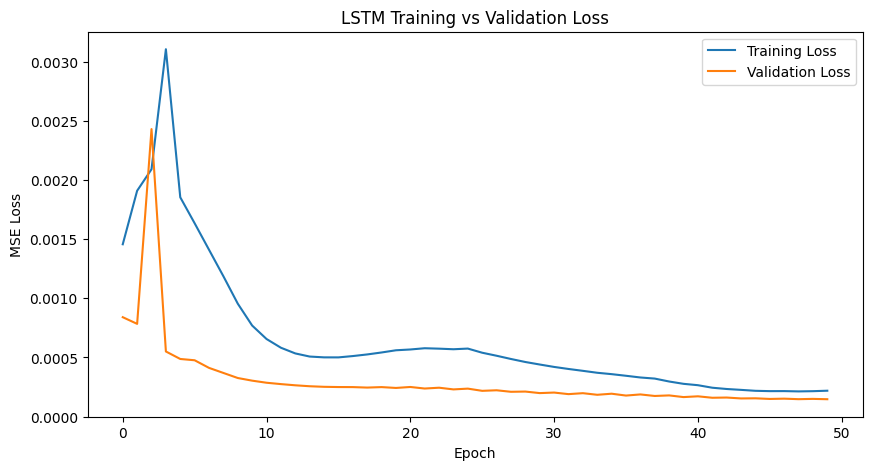

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("LSTM Training vs Validation Loss")

plt.legend()

plt.show()

In [34]:
predictions_scaled = model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [35]:
print(predictions_scaled.shape)

(796, 1)


In [36]:
predictions = scaler.inverse_transform(
    predictions_scaled
)

actual = scaler.inverse_transform(
    y_test
)

In [37]:
print("Predicted:")
print(predictions[:5])

print("\nActual:")
print(actual[:5])

Predicted:
[[905.6432 ]
 [911.1155 ]
 [910.13324]
 [919.949  ]
 [934.8605 ]]

Actual:
[[904.55]
 [897.85]
 [915.5 ]
 [933.65]
 [935.65]]


In [38]:
mae = mean_absolute_error(
    actual,
    predictions
)

print("MAE:", mae)

MAE: 30.694077948948834


In [39]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 42.344692535998234


In [40]:
mape = np.mean(
    np.abs(
        (actual - predictions) / actual
    )
) * 100

print("MAPE:", mape)

MAPE: 2.0001004104679123


In [41]:
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 30.69
RMSE : 42.34
MAPE : 2.00%


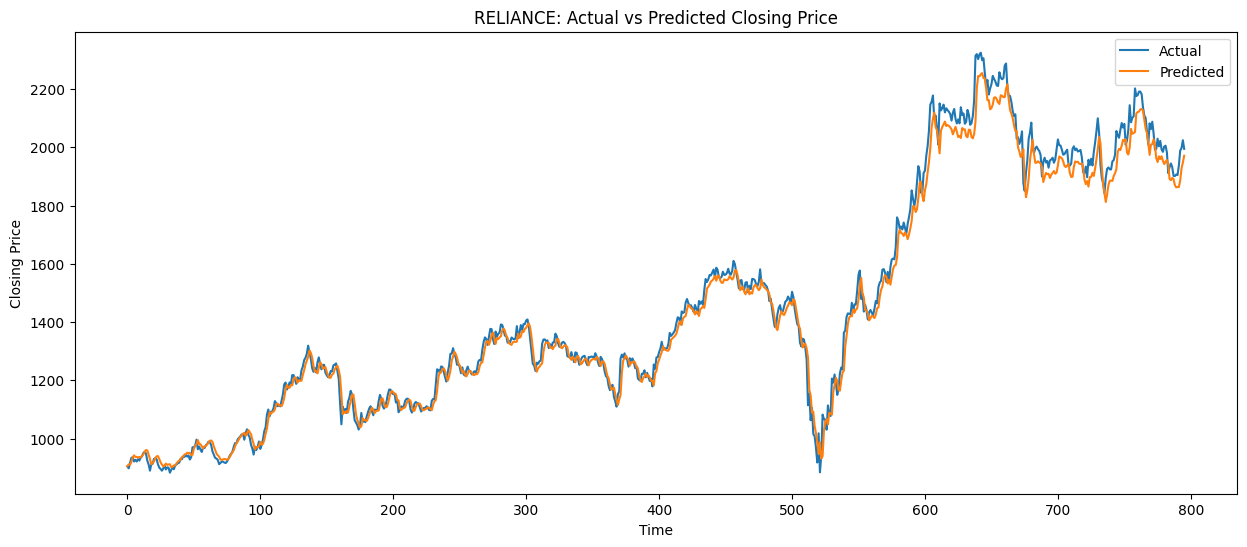

In [42]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Closing Price")

plt.title(
    "RELIANCE: Actual vs Predicted Closing Price"
)

plt.legend()

plt.show()

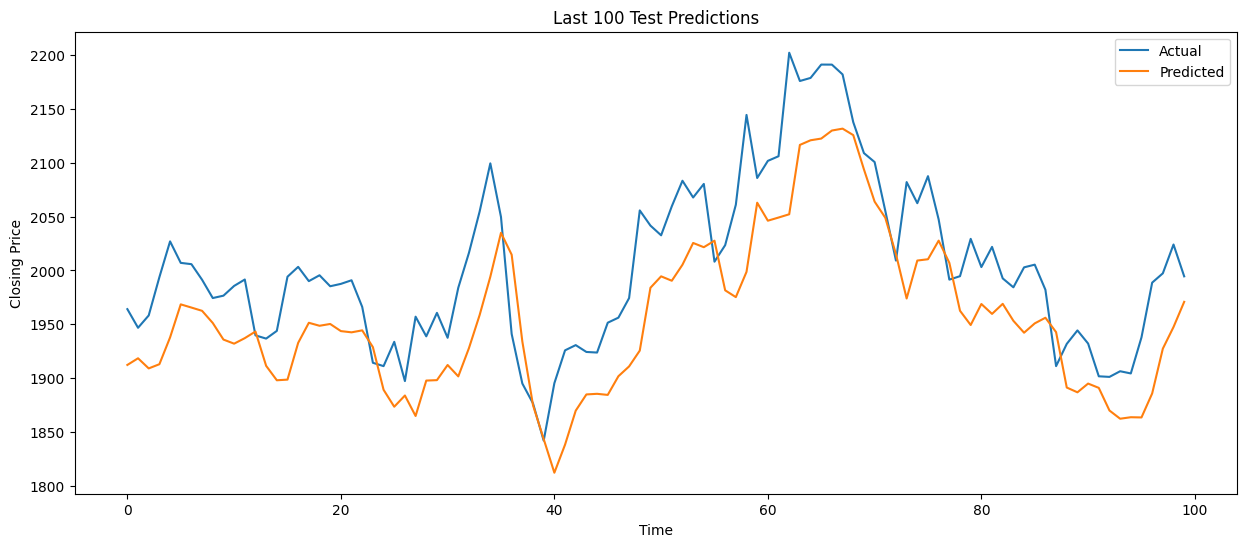

In [43]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual[-100:],
    label="Actual"
)

plt.plot(
    predictions[-100:],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Closing Price")

plt.title(
    "Last 100 Test Predictions"
)

plt.legend()

plt.show()

In [44]:
last_30 = scaled_data[-window_size:]

In [45]:
print(last_30.shape)

(30, 1)


In [46]:
X_next = last_30.reshape(
    1,
    window_size,
    1
)

In [47]:
next_prediction_scaled = model.predict(
    X_next
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [48]:
next_prediction = scaler.inverse_transform(
    next_prediction_scaled
)

In [49]:
print(
    "Predicted next closing price:",
    next_prediction[0][0]
)
next_prediction

Predicted next closing price: 1958.2262


array([[1958.2262]], dtype=float32)

In [50]:
last_actual_price = data["Close"].iloc[-1]

predicted_price = next_prediction[0][0]

print("Last actual closing price :", last_actual_price)
print("Predicted next price      :", predicted_price)

change = predicted_price - last_actual_price

print("Predicted change          :", change)

percentage_change = (
    change / last_actual_price
) * 100

print(
    "Predicted % change        :",
    percentage_change,
    "%"
)

Last actual closing price : 1994.5
Predicted next price      : 1958.2262
Predicted change          : -36.2738037109375
Predicted % change        : -1.818691587412259 %


In [51]:
print("=" * 50)
print("LSTM TIME-SERIES FORECASTING")
print("=" * 50)

print("Stock: RELIANCE")
print("Window size:", window_size)
print("LSTM units: 64")
print("Batch size: 32")

print("\nPerformance")
print("-" * 30)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

print("\nNext-day prediction")
print("-" * 30)

print(f"Predicted price: ₹{predicted_price:.2f}")

LSTM TIME-SERIES FORECASTING
Stock: RELIANCE
Window size: 30
LSTM units: 64
Batch size: 32

Performance
------------------------------
MAE  : 30.69
RMSE : 42.34
MAPE : 2.00%

Next-day prediction
------------------------------
Predicted price: ₹1958.23
